In [12]:
# ============================================
# PART 1: IMPORTS & DATABASE CONNECTION
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine
from dotenv import load_dotenv

import os

# ============================================
# LOAD ENVIRONMENT VARIABLES
# ============================================

load_dotenv()

# ============================================
# DATABASE CONNECTION
# ============================================

connection_string = (
    f"postgresql+psycopg2://"
    f"{os.getenv('DB_USER')}:"
    f"{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:"
    f"{os.getenv('DB_PORT')}/"
    f"{os.getenv('DB_NAME')}"
)

engine = create_engine(connection_string)

print("✅ PostgreSQL Connected Successfully")

# ============================================
# LOAD TABLES
# ============================================

providers = pd.read_sql(
    "SELECT * FROM providers",
    engine
)

receivers = pd.read_sql(
    "SELECT * FROM receivers",
    engine
)

food_listings = pd.read_sql(
    "SELECT * FROM food_listings",
    engine
)

claims = pd.read_sql(
    "SELECT * FROM claims",
    engine
)

print("\n📊 DATASETS LOADED")

print(
    f"Providers     : {providers.shape}"
)

print(
    f"Receivers     : {receivers.shape}"
)

print(
    f"Food Listings : {food_listings.shape}"
)

print(
    f"Claims        : {claims.shape}"
)

✅ PostgreSQL Connected Successfully

📊 DATASETS LOADED
Providers     : (1000, 6)
Receivers     : (1000, 5)
Food Listings : (1000, 9)
Claims        : (1000, 5)


In [13]:
# ============================================
# PART 2: DATA OVERVIEW
# ============================================

datasets = {
    "Providers": providers,
    "Receivers": receivers,
    "Food Listings": food_listings,
    "Claims": claims
}

for name, df in datasets.items():

    print("\n" + "="*60)
    print(f"{name.upper()}")
    print("="*60)

    print("\nShape:")
    print(df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nData Types:")
    print(df.dtypes)

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nDuplicate Rows:")
    print(df.duplicated().sum())

    print("\nSample Records:")
    display(df.head())


PROVIDERS

Shape:
(1000, 6)

Columns:
['provider_id', 'name', 'type', 'address', 'city', 'contact']

Data Types:
provider_id    int64
name             str
type             str
address          str
city             str
contact          str
dtype: object

Missing Values:
provider_id    0
name           0
type           0
address        0
city           0
contact        0
dtype: int64

Duplicate Rows:
0

Sample Records:


,provider_id,name,type,address,city,contact
0,1,Gonzales-Cochran,Supermarket,"74347 Christopher Extensions\nAndreamouth, OK ...",New Jessica,+1-600-220-0480
1,2,"Nielsen, Johnson and Fuller",Grocery Store,"91228 Hanson Stream\nWelchtown, OR 27136",East Sheena,+1-925-283-8901x6297
2,3,Miller-Black,Supermarket,"561 Martinez Point Suite 507\nGuzmanchester, W...",Lake Jesusview,001-517-295-2206
3,4,"Clark, Prince and Williams",Grocery Store,"467 Bell Trail Suite 409\nPort Jesus, IA 61188",Mendezmouth,556.944.8935x401
4,5,Coleman-Farley,Grocery Store,"078 Matthew Creek Apt. 319\nSaraborough, MA 53978",Valentineside,193.714.6577



RECEIVERS

Shape:
(1000, 5)

Columns:
['receiver_id', 'name', 'type', 'city', 'contact']

Data Types:
receiver_id    int64
name             str
type             str
city             str
contact          str
dtype: object

Missing Values:
receiver_id    0
name           0
type           0
city           0
contact        0
dtype: int64

Duplicate Rows:
0

Sample Records:


,receiver_id,name,type,city,contact
0,1,Donald Gomez,Shelter,Port Carlburgh,(955)922-5295
1,2,Laurie Ramos,Individual,Lewisburgh,761.042.1570
2,3,Ashley Mckee,NGO,South Randalltown,691-023-0094x856
3,4,Erika Rose,NGO,South Shaneville,8296491111
4,5,John Romero,Individual,Bakerport,067.491.0154



FOOD LISTINGS

Shape:
(1000, 9)

Columns:
['food_id', 'food_name', 'quantity', 'expiry_date', 'provider_id', 'provider_type', 'location', 'food_type', 'meal_type']

Data Types:
food_id           int64
food_name           str
quantity          int64
expiry_date      object
provider_id       int64
provider_type       str
location            str
food_type           str
meal_type           str
dtype: object

Missing Values:
food_id          0
food_name        0
quantity         0
expiry_date      0
provider_id      0
provider_type    0
location         0
food_type        0
meal_type        0
dtype: int64

Duplicate Rows:
0

Sample Records:


,food_id,food_name,quantity,expiry_date,provider_id,provider_type,location,food_type,meal_type
0,1,Bread,43,2025-03-17,110,Grocery Store,South Kellyville,Non-Vegetarian,Breakfast
1,2,Soup,22,2025-03-24,791,Grocery Store,West James,Non-Vegetarian,Dinner
2,3,Fruits,46,2025-03-28,478,Catering Service,Lake Regina,Vegan,Breakfast
3,4,Fruits,15,2025-03-16,930,Restaurant,Kellytown,Vegan,Lunch
4,5,Soup,14,2025-03-19,279,Restaurant,Garciaport,Vegan,Dinner



CLAIMS

Shape:
(1000, 5)

Columns:
['claim_id', 'food_id', 'receiver_id', 'status', 'timestamp']

Data Types:
claim_id                int64
food_id                 int64
receiver_id             int64
status                    str
timestamp      datetime64[us]
dtype: object

Missing Values:
claim_id       0
food_id        0
receiver_id    0
status         0
timestamp      0
dtype: int64

Duplicate Rows:
0

Sample Records:


,claim_id,food_id,receiver_id,status,timestamp
0,1,164,908,Pending,2025-03-05 05:26:00
1,2,353,391,Cancelled,2025-03-11 10:24:00
2,3,626,492,Completed,2025-03-21 00:59:00
3,4,61,933,Cancelled,2025-03-04 09:08:00
4,5,345,229,Pending,2025-03-14 15:17:00


In [14]:
# ============================================
# PART 3: DATA CLEANING & VALIDATION
# ============================================

print("\n" + "="*60)
print("DATA CLEANING")
print("="*60)

# --------------------------------------------
# Standardize Column Names
# --------------------------------------------

providers.columns = providers.columns.str.lower()
receivers.columns = receivers.columns.str.lower()
food_listings.columns = food_listings.columns.str.lower()
claims.columns = claims.columns.str.lower()

print("✅ Column names converted to lowercase")

# --------------------------------------------
# Convert Date Columns
# --------------------------------------------

food_listings["expiry_date"] = pd.to_datetime(
    food_listings["expiry_date"]
)

claims["timestamp"] = pd.to_datetime(
    claims["timestamp"]
)

print("✅ Date columns converted")

# --------------------------------------------
# Missing Values Check
# --------------------------------------------

print("\nMissing Values")

for name, df in {
    "Providers": providers,
    "Receivers": receivers,
    "Food Listings": food_listings,
    "Claims": claims
}.items():

    print(f"\n{name}")

    print(
        df.isnull().sum()
    )

# --------------------------------------------
# Duplicate Records Check
# --------------------------------------------

print("\nDuplicate Records")

for name, df in {
    "Providers": providers,
    "Receivers": receivers,
    "Food Listings": food_listings,
    "Claims": claims
}.items():

    print(
        f"{name}: {df.duplicated().sum()}"
    )

# --------------------------------------------
# Unique Values Check
# --------------------------------------------

print("\nUnique Value Summary")

print(
    "\nProvider Types:"
)

print(
    providers["type"].value_counts()
)

print(
    "\nReceiver Types:"
)

print(
    receivers["type"].value_counts()
)

print(
    "\nFood Types:"
)

print(
    food_listings["food_type"].value_counts()
)

print(
    "\nMeal Types:"
)

print(
    food_listings["meal_type"].value_counts()
)

print(
    "\nClaim Status:"
)

print(
    claims["status"].value_counts()
)

print("\n✅ Data Validation Complete")


DATA CLEANING
✅ Column names converted to lowercase
✅ Date columns converted

Missing Values

Providers
provider_id    0
name           0
type           0
address        0
city           0
contact        0
dtype: int64

Receivers
receiver_id    0
name           0
type           0
city           0
contact        0
dtype: int64

Food Listings
food_id          0
food_name        0
quantity         0
expiry_date      0
provider_id      0
provider_type    0
location         0
food_type        0
meal_type        0
dtype: int64

Claims
claim_id       0
food_id        0
receiver_id    0
status         0
timestamp      0
dtype: int64

Duplicate Records
Providers: 0
Receivers: 0
Food Listings: 0
Claims: 0

Unique Value Summary

Provider Types:
type
Supermarket         262
Grocery Store       256
Restaurant          246
Catering Service    236
Name: count, dtype: int64

Receiver Types:
type
NGO           274
Charity       263
Shelter       246
Individual    217
Name: count, dtype: int64

Food Ty

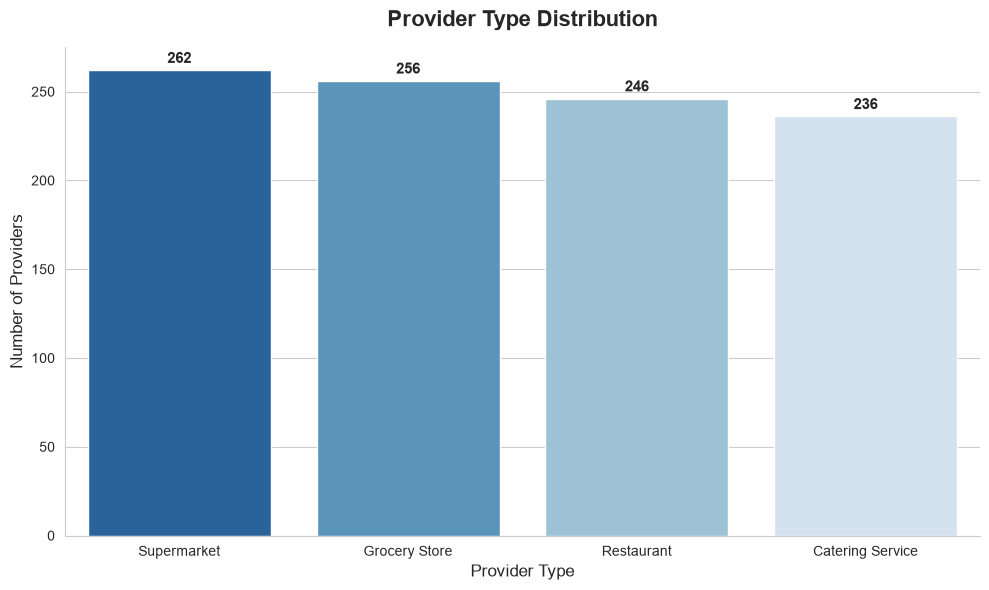

In [15]:
# ============================================
# PROVIDER TYPE DISTRIBUTION
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Provider Type Counts
provider_type_counts = (
    providers["type"]
    .value_counts()
    .reset_index()
)

provider_type_counts.columns = [
    "provider_type",
    "count"
]

# Style
sns.set_style("whitegrid")

# Figure
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=provider_type_counts,
    x="provider_type",
    y="count",
    hue="provider_type",
    palette="Blues_r",
    legend=False
)

# Title & Labels
plt.title(
    "Provider Type Distribution",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Provider Type",
    fontsize=12
)

plt.ylabel(
    "Number of Providers",
    fontsize=12
)

# Value Labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,
        fontsize=11,
        fontweight="bold"
    )

# Remove Top/Right Borders
sns.despine()

plt.tight_layout()

# Save Image
plt.savefig(
    "Image/provider_type_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight
Provider participation is relatively balanced across all four provider categories.
Supermarkets contribute the largest share of providers (262), followed closely by Grocery Stores (256), Restaurants (246), and Catering Services (236).
The small differences between categories suggest the platform is not heavily dependent on a single provider type, indicating a diversified food donation network.

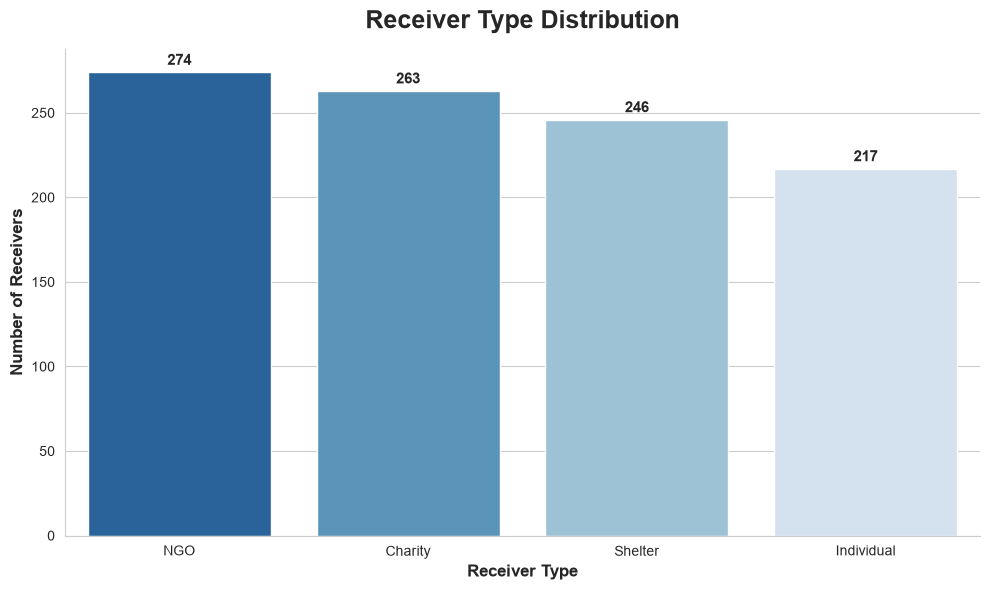

In [17]:
# ============================================
# RECEIVER TYPE DISTRIBUTION
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Count receiver types
receiver_type_counts = (
    receivers["type"]
    .value_counts()
    .reset_index()
)

receiver_type_counts.columns = [
    "Receiver Type",
    "Count"
]

# Modern styling
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=receiver_type_counts,
    x="Receiver Type",
    y="Count",
    hue="Receiver Type",
    palette="Blues_r",
    legend=False
)

# Title
plt.title(
    "Receiver Type Distribution",
    fontsize=18,
    fontweight="bold",
    pad=15
)

# Axis Labels
plt.xlabel(
    "Receiver Type",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Receivers",
    fontsize=12,
    fontweight="bold"
)

# Value Labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,
        fontsize=11,
        fontweight="bold"
    )

# Remove Top/Right Borders
sns.despine()

plt.tight_layout()

# Save Image
plt.savefig(
    "Image/receiver_type_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

NGOs represent the largest beneficiary group on the platform with 274 receivers, followed by Charities (263) and Shelters (246), while Individuals account for 217 receivers. The relatively balanced distribution suggests that food redistribution efforts are reaching a diverse mix of recipients rather than being concentrated in a single group. From a stakeholder perspective, the strong participation of NGOs, Charities, and Shelters indicates that the platform is successfully engaging organizations that support vulnerable populations and community welfare.

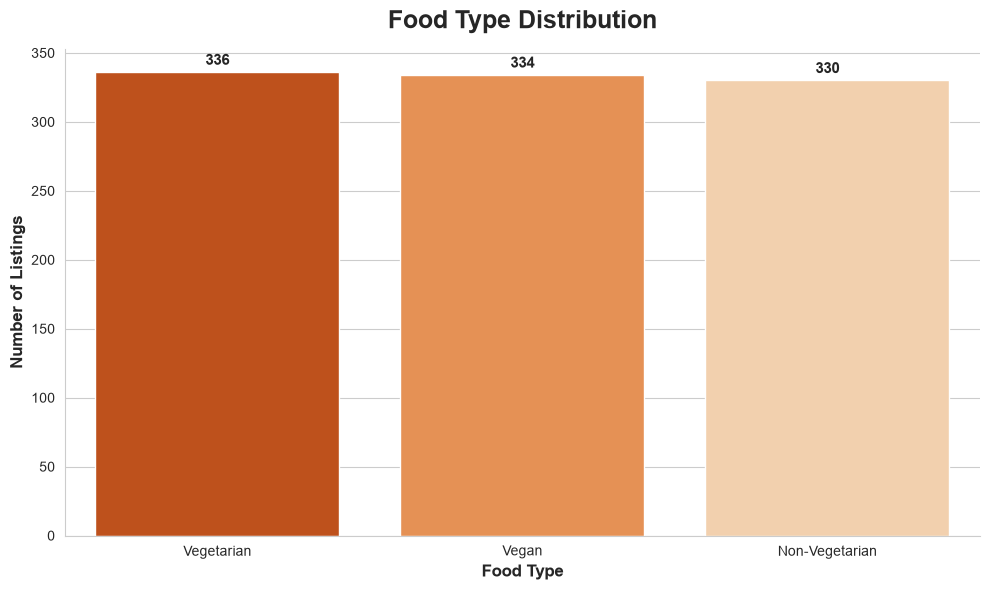

In [18]:
# ============================================
# FOOD TYPE DISTRIBUTION
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Count Food Types
food_type_counts = (
    food_listings["food_type"]
    .value_counts()
    .reset_index()
)

food_type_counts.columns = [
    "Food Type",
    "Count"
]

# Modern Styling
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=food_type_counts,
    x="Food Type",
    y="Count",
    hue="Food Type",
    palette="Oranges_r",
    legend=False
)

# Title
plt.title(
    "Food Type Distribution",
    fontsize=18,
    fontweight="bold",
    pad=15
)

# Axis Labels
plt.xlabel(
    "Food Type",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Listings",
    fontsize=12,
    fontweight="bold"
)

# Value Labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,
        fontsize=11,
        fontweight="bold"
    )

# Remove unnecessary borders
sns.despine()

plt.tight_layout()

# Save Image
plt.savefig(
    "Image/food_type_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

The platform maintains a highly balanced distribution of food types, with Vegetarian (336), Vegan (334), and Non-Vegetarian (330) listings appearing in nearly equal proportions. This suggests that food availability is not concentrated in a single dietary category, allowing the platform to support a broad range of recipient dietary preferences and requirements. For stakeholders, the balanced inventory indicates an inclusive food supply that can serve diverse beneficiary groups without significant dietary bias.

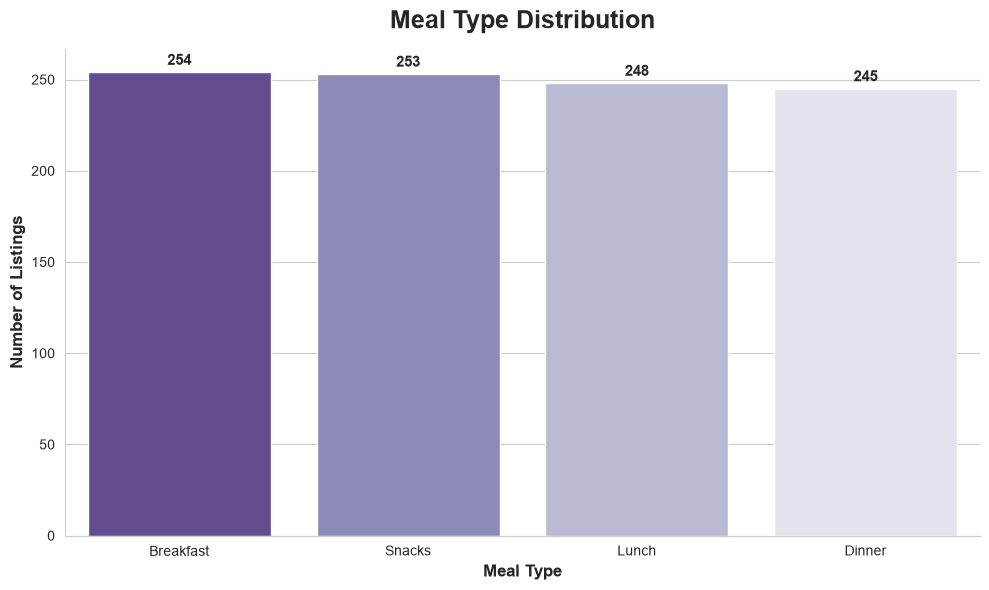

In [19]:
# ============================================
# MEAL TYPE DISTRIBUTION
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Count Meal Types
meal_type_counts = (
    food_listings["meal_type"]
    .value_counts()
    .reset_index()
)

meal_type_counts.columns = [
    "Meal Type",
    "Count"
]

# Modern Styling
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=meal_type_counts,
    x="Meal Type",
    y="Count",
    hue="Meal Type",
    palette="Purples_r",
    legend=False
)

# Title
plt.title(
    "Meal Type Distribution",
    fontsize=18,
    fontweight="bold",
    pad=15
)

# Axis Labels
plt.xlabel(
    "Meal Type",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Listings",
    fontsize=12,
    fontweight="bold"
)

# Value Labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,
        fontsize=11,
        fontweight="bold"
    )

# Clean Look
sns.despine()

plt.tight_layout()

# Save Image
plt.savefig(
    "Image/meal_type_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

The platform maintains a balanced distribution of meal offerings, with Breakfast (254) and Snacks (253) appearing slightly more frequently than Lunch (248) and Dinner (245). The small differences across categories suggest that food availability is spread consistently throughout the day rather than being concentrated around a specific meal period. For stakeholders, this indicates that recipients have access to a diverse mix of meal options, supporting food redistribution needs across multiple consumption occasions.

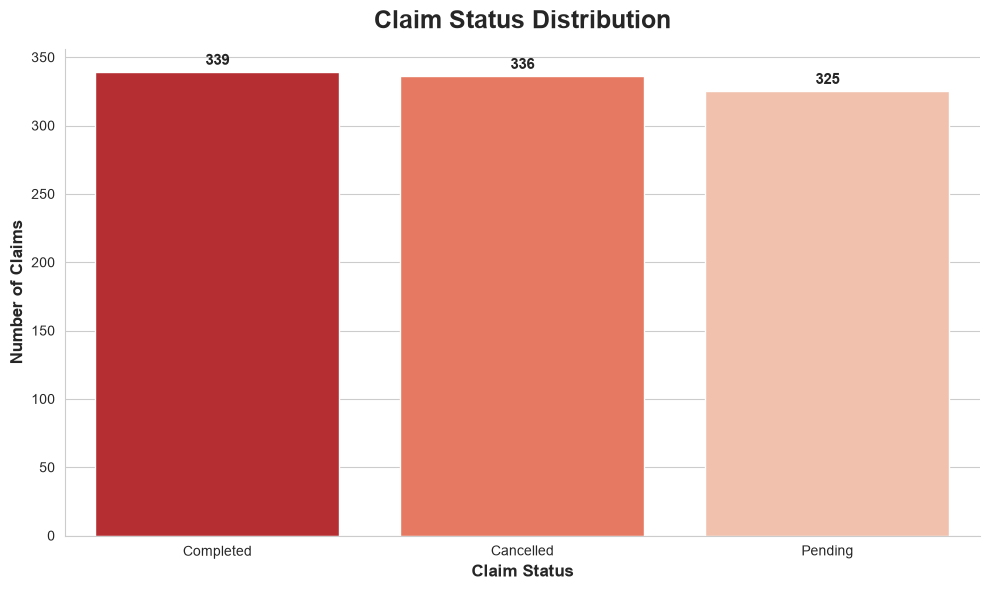

In [21]:
# ============================================
# CLAIM STATUS DISTRIBUTION
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Count Claim Statuses
claim_status_counts = (
    claims["status"]
    .value_counts()
    .reset_index()
)

claim_status_counts.columns = [
    "Claim Status",
    "Count"
]

# Modern Styling
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=claim_status_counts,
    x="Claim Status",
    y="Count",
    hue="Claim Status",
    palette="Reds_r",
    legend=False
)

# Title
plt.title(
    "Claim Status Distribution",
    fontsize=18,
    fontweight="bold",
    pad=15
)

# Axis Labels
plt.xlabel(
    "Claim Status",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Claims",
    fontsize=12,
    fontweight="bold"
)

# Value Labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,
        fontsize=11,
        fontweight="bold"
    )

# Clean Look
sns.despine()

plt.tight_layout()

# Save Image
plt.savefig(
    "Image/claim_status_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

Completed claims account for 339 records (33.9%), slightly exceeding Cancelled (336) and Pending (325) claims. While completed claims represent the largest category, the near-equal distribution across all three statuses suggests that a substantial portion of food requests are either not finalized or remain unresolved. With a claim completion rate of only 33.9%, the platform has significant room to improve food redistribution efficiency by reducing cancellations and accelerating claim fulfillment. From a stakeholder perspective, this chart highlights operational effectiveness rather than platform participation, making it one of the most important indicators of overall platform performance.

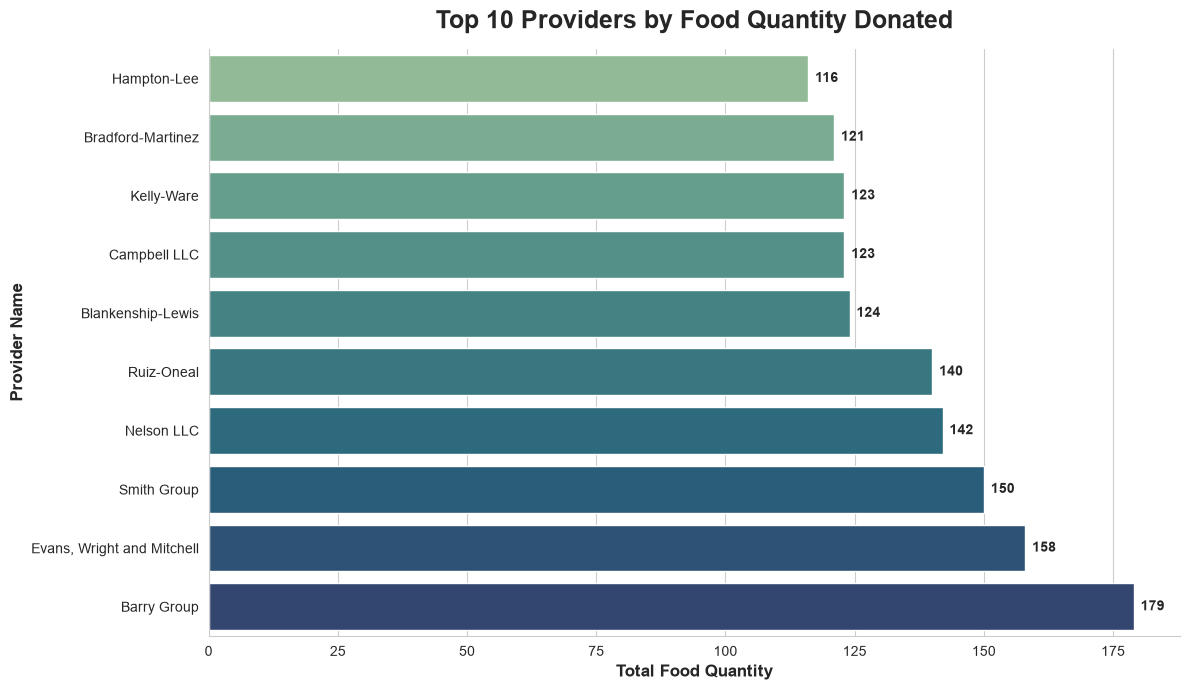

In [22]:
# ============================================
# TOP 10 PROVIDERS BY FOOD QUANTITY
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate quantity by provider
provider_quantity = (
    food_listings
    .groupby("provider_id")["quantity"]
    .sum()
    .reset_index()
)

provider_quantity.columns = [
    "provider_id",
    "Total Quantity"
]

# Merge Provider Names
provider_quantity = provider_quantity.merge(
    providers[["provider_id", "name"]],
    on="provider_id",
    how="left"
)

# Top 10 Providers
top_10_providers = (
    provider_quantity
    .nlargest(10, "Total Quantity")
    .sort_values("Total Quantity")
)

# Styling
sns.set_style("whitegrid")

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=top_10_providers,
    x="Total Quantity",
    y="name",
    hue="name",
    palette="crest",
    legend=False
)

# Title
plt.title(
    "Top 10 Providers by Food Quantity Donated",
    fontsize=18,
    fontweight="bold",
    pad=15
)

# Labels
plt.xlabel(
    "Total Food Quantity",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Provider Name",
    fontsize=12,
    fontweight="bold"
)

# Value Labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=5,
        fontsize=10,
        fontweight="bold"
    )

# Remove extra borders
sns.despine()

plt.tight_layout()

# Save Image
plt.savefig(
    "Image/top_10_providers_quantity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

The top 10 providers contribute substantially larger food quantities than the average provider, highlighting a small group of high-impact donors within the platform. Barry Group leads all providers with 179 units donated, approximately 54% more than Hampton-Lee, which contributes 116 units at the lower end of the top 10. Unlike listing counts, which measure activity, total quantity donated reflects the actual volume of food made available for redistribution and therefore provides a stronger indicator of provider impact. For stakeholders, these top contributors represent valuable partners whose continued participation can significantly influence the platform's ability to reduce food waste and support recipient organizations.

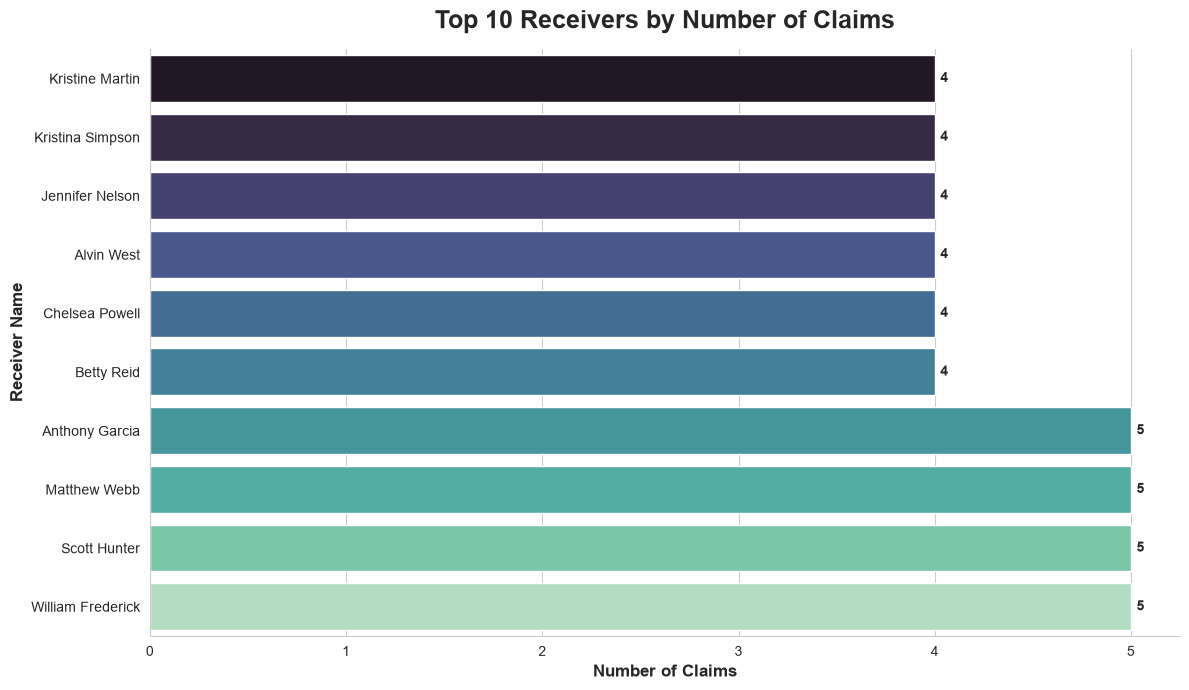

In [23]:
# ============================================
# TOP 10 RECEIVERS BY NUMBER OF CLAIMS
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Claims by Receiver
receiver_claims = (
    claims
    .groupby("receiver_id")["claim_id"]
    .count()
    .reset_index()
)

receiver_claims.columns = [
    "receiver_id",
    "Total Claims"
]

# Merge Receiver Names
receiver_claims = receiver_claims.merge(
    receivers[["receiver_id", "name"]],
    on="receiver_id",
    how="left"
)

# Top 10 Receivers
top_10_receivers = (
    receiver_claims
    .nlargest(10, "Total Claims")
    .sort_values("Total Claims")
)

# Styling
sns.set_style("whitegrid")

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=top_10_receivers,
    x="Total Claims",
    y="name",
    hue="name",
    palette="mako",
    legend=False
)

# Title
plt.title(
    "Top 10 Receivers by Number of Claims",
    fontsize=18,
    fontweight="bold",
    pad=15
)

# Labels
plt.xlabel(
    "Number of Claims",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Receiver Name",
    fontsize=12,
    fontweight="bold"
)

# Value Labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=4,
        fontsize=10,
        fontweight="bold"
    )

# Clean Appearance
sns.despine()

plt.tight_layout()

# Save Image
plt.savefig(
    "Image/top_10_receivers_claims.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

The most active receivers made only 4–5 claims each, suggesting relatively even platform usage with no single beneficiary dominating food redistribution activity. While these receivers are among the most engaged users of the platform, the small differences between the top 10 indicate that demand is broadly distributed across the receiver network rather than concentrated among a few organizations or individuals. For stakeholders, this pattern suggests equitable access to food resources and a balanced distribution of platform participation.

In [24]:
# ============================================
# CREATE CLAIMS_ANALYSIS DATASET
# ============================================

claims_analysis = claims.merge(
    food_listings[
        [
            "food_id",
            "expiry_date",
            "food_type",
            "meal_type",
            "quantity",
            "provider_type"
        ]
    ],
    on="food_id",
    how="left"
)

# Ensure datetime format
claims_analysis["expiry_date"] = pd.to_datetime(
    claims_analysis["expiry_date"]
)

claims_analysis["timestamp"] = pd.to_datetime(
    claims_analysis["timestamp"]
)

# Days remaining until expiry
claims_analysis["days_until_expiry"] = (
    claims_analysis["expiry_date"]
    -
    claims_analysis["timestamp"]
).dt.days

print("✅ claims_analysis created successfully")

print(
    f"Dataset Shape: {claims_analysis.shape}"
)

claims_analysis.head()

✅ claims_analysis created successfully
Dataset Shape: (1000, 11)


,claim_id,food_id,receiver_id,status,timestamp,expiry_date,food_type,meal_type,quantity,provider_type,days_until_expiry
0,1,164,908,Pending,2025-03-05 05:26:00,2025-03-27,Vegan,Dinner,22,Restaurant,21
1,2,353,391,Cancelled,2025-03-11 10:24:00,2025-03-29,Non-Vegetarian,Lunch,5,Restaurant,17
2,3,626,492,Completed,2025-03-21 00:59:00,2025-03-29,Non-Vegetarian,Breakfast,37,Supermarket,7
3,4,61,933,Cancelled,2025-03-04 09:08:00,2025-03-22,Vegetarian,Lunch,33,Catering Service,17
4,5,345,229,Pending,2025-03-14 15:17:00,2025-03-20,Vegan,Lunch,14,Grocery Store,5


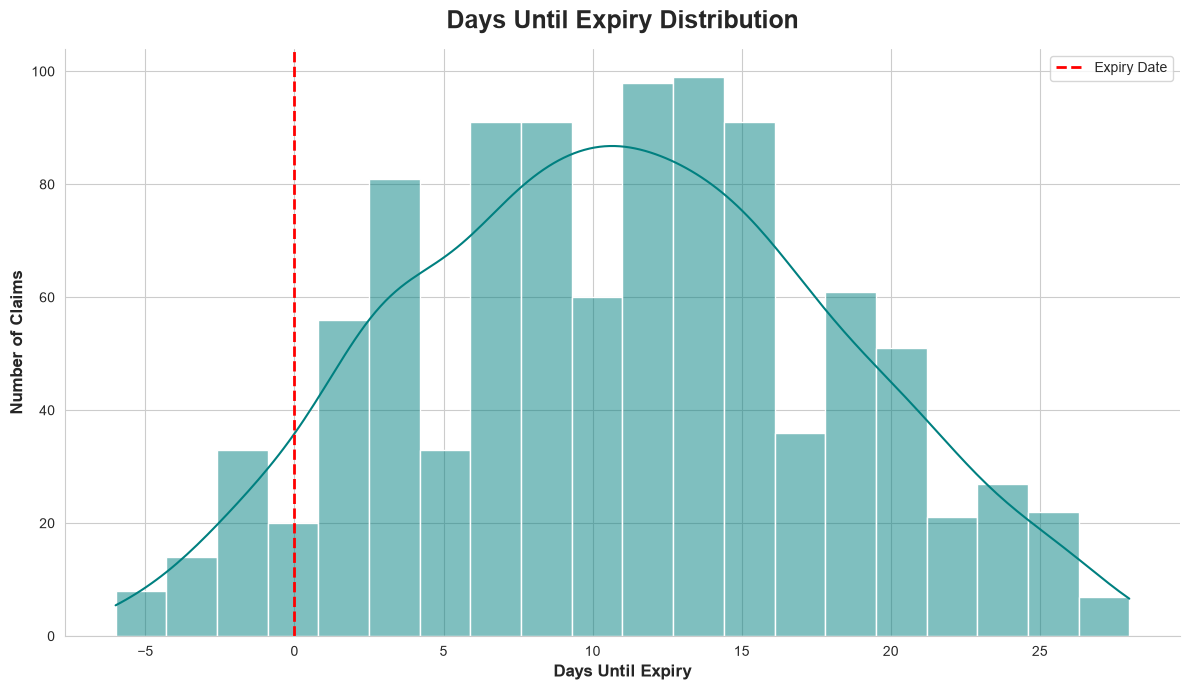

In [25]:
# ============================================
# DAYS UNTIL EXPIRY DISTRIBUTION
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Modern Styling
sns.set_style("whitegrid")

plt.figure(figsize=(12, 7))

ax = sns.histplot(
    data=claims_analysis,
    x="days_until_expiry",
    bins=20,
    kde=True,
    color="teal"
)

# Expiry Line
plt.axvline(
    x=0,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Expiry Date"
)

# Title
plt.title(
    "Days Until Expiry Distribution",
    fontsize=18,
    fontweight="bold",
    pad=15
)

# Labels
plt.xlabel(
    "Days Until Expiry",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Claims",
    fontsize=12,
    fontweight="bold"
)

# Legend
plt.legend()

# Clean Look
sns.despine()

plt.tight_layout()

# Save Image
plt.savefig(
    "Image/days_until_expiry_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

Most food claims occur well before the expiry date, with an average lead time of approximately 10.9 days. The distribution is concentrated in the positive range, indicating that the platform generally facilitates food redistribution before products expire. However, the small portion of the distribution falling below zero represents 55 claims (5.5%) made after expiry, including 15 completed claims. For stakeholders, this suggests that while the platform is largely effective at preventing food waste, there may be opportunities to strengthen expiry monitoring and claim validation processes.

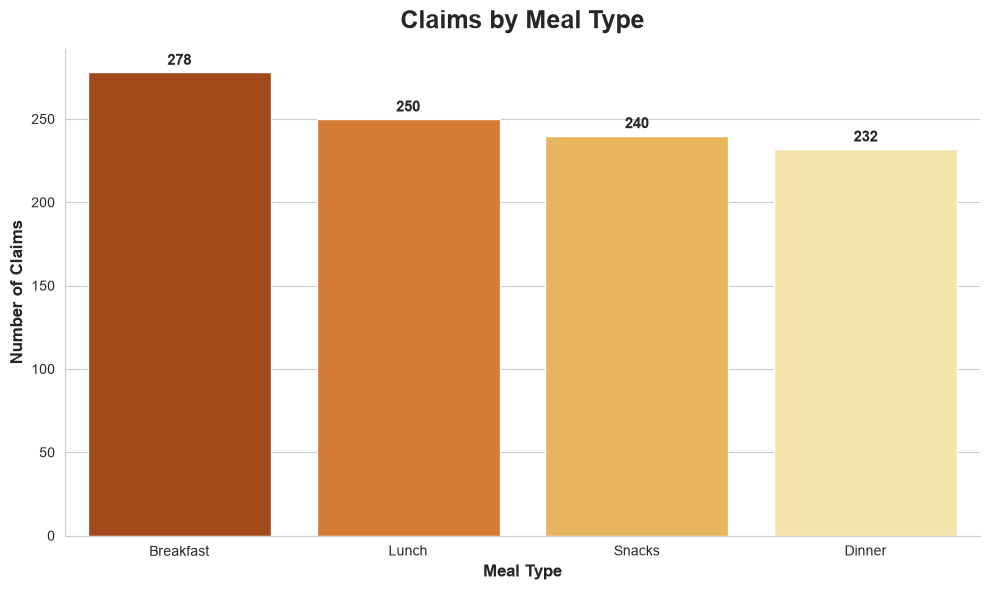

In [26]:
# ============================================
# CLAIMS BY MEAL TYPE
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Merge Claims with Food Listings
claims_meal_type = claims.merge(
    food_listings[
        ["food_id", "meal_type"]
    ],
    on="food_id",
    how="left"
)

# Count Claims by Meal Type
meal_claims = (
    claims_meal_type["meal_type"]
    .value_counts()
    .reset_index()
)

meal_claims.columns = [
    "Meal Type",
    "Claim Count"
]

# Modern Styling
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=meal_claims,
    x="Meal Type",
    y="Claim Count",
    hue="Meal Type",
    palette="YlOrBr_r",
    legend=False
)

# Title
plt.title(
    "Claims by Meal Type",
    fontsize=18,
    fontweight="bold",
    pad=15
)

# Axis Labels
plt.xlabel(
    "Meal Type",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Claims",
    fontsize=12,
    fontweight="bold"
)

# Value Labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,
        fontsize=11,
        fontweight="bold"
    )

# Clean Appearance
sns.despine()

plt.tight_layout()

# Save Image
plt.savefig(
    "Image/claims_by_meal_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

Breakfast generated the highest number of claims (278), compared with 254 available breakfast listings, resulting in a claim-to-listing ratio above 1.0. In contrast, Lunch (250 claims vs. 248 listings), Snacks (240 vs. 253), and Dinner (232 vs. 245) showed demand levels that more closely matched availability.

Comparing this chart with the Meal Type Distribution chart suggests that demand generally mirrors supply across meal categories, but Breakfast exhibits slightly stronger demand relative to availability. For stakeholders, this may indicate an opportunity to prioritize breakfast donations to better align food supply with recipient demand.